# Patterns of Being Rich — Data Cleaning & Processing

**Dataset:** Billionaires Statistics (2023 snapshot) + Historical Billionaires (1996–2014)  
**Goal:** Clean, explore, and prepare both datasets for analysis and visualization.

## Step 1: Import Libraries & Load Data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load datasets
df = pd.read_csv('data/Billionaires Statistics Dataset.csv')       # 2023 snapshot
df_hist = pd.read_csv('data/billionaires.csv')                     # historical 1996-2014

print(f'2023 snapshot : {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Historical    : {df_hist.shape[0]} rows, {df_hist.shape[1]} columns')

2023 snapshot : 2640 rows, 35 columns
Historical    : 2614 rows, 22 columns


## Step 2: Inspect the Data

In [25]:
# --- 2023 snapshot ---
print("=== 2023 SNAPSHOT COLUMNS & TYPES ===")
print(df.dtypes)
print("\n--- First 3 rows ---")
df.head(3)

=== 2023 SNAPSHOT COLUMNS & TYPES ===
rank                                            int64
finalWorth                                      int64
category                                       object
personName                                     object
age                                           float64
country                                        object
city                                           object
source                                         object
industries                                     object
countryOfCitizenship                           object
organization                                   object
selfMade                                         bool
status                                         object
gender                                         object
birthDate                                      object
lastName                                       object
firstName                                      object
title                                       

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,organization,selfMade,status,gender,birthDate,lastName,firstName,title,date,state,residenceStateRegion,birthYear,birthMonth,birthDay,cpi_country,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.00,France,Paris,LVMH,Fashion & Retail,France,LVMH Moët Hennessy Louis Vuitton,False,U,M,3/5/1949 0:00,Arnault,Bernard,Chairman and CEO,4/4/2023 5:01,NaN,NaN,1949.00,3.00,5.00,110.05,1.10,"$2,715,518,274,227",65.60,102.50,82.50,24.20,60.70,67059887.00,46.23,2.21
1,2,180000,Automotive,Elon Musk,51.00,United States,Austin,"Tesla, SpaceX",Automotive,United States,Tesla,True,D,M,6/28/1971 0:00,Musk,Elon,CEO,4/4/2023 5:01,Texas,South,1971.00,6.00,28.00,117.24,7.50,"$21,427,700,000,000",88.20,101.80,78.50,9.60,36.60,328239523.00,37.09,-95.71
2,3,114000,Technology,Jeff Bezos,59.00,United States,Medina,Amazon,Technology,United States,Amazon,True,D,M,1/12/1964 0:00,Bezos,Jeff,Chairman and Founder,4/4/2023 5:01,Washington,West,1964.00,1.00,12.00,117.24,7.50,"$21,427,700,000,000",88.20,101.80,78.50,9.60,36.60,328239523.00,37.09,-95.71


In [26]:
# --- Historical dataset ---
print("=== HISTORICAL COLUMNS & TYPES ===")
print(df_hist.dtypes)
print("\n--- First 3 rows ---")
df_hist.head(3)

=== HISTORICAL COLUMNS & TYPES ===
name                         object
rank                          int64
year                          int64
company.founded               int64
company.name                 object
company.relationship         object
company.sector               object
company.type                 object
demographics.age              int64
demographics.gender          object
location.citizenship         object
location.country code        object
location.gdp                float64
location.region              object
wealth.type                  object
wealth.worth in billions    float64
wealth.how.category          object
wealth.how.from emerging       bool
wealth.how.industry          object
wealth.how.inherited         object
wealth.how.was founder         bool
wealth.how.was political       bool
dtype: object

--- First 3 rows ---


,name,rank,year,company.founded,company.name,company.relationship,company.sector,company.type,demographics.age,demographics.gender,location.citizenship,location.country code,location.gdp,location.region,wealth.type,wealth.worth in billions,wealth.how.category,wealth.how.from emerging,wealth.how.industry,wealth.how.inherited,wealth.how.was founder,wealth.how.was political
0,Bill Gates,1,1996,1975,Microsoft,founder,Software,new,40,male,United States,USA,8100000000000.00,North America,founder non-finance,18.50,New Sectors,True,Technology-Computer,not inherited,True,True
1,Bill Gates,1,2001,1975,Microsoft,founder,Software,new,45,male,United States,USA,10600000000000.00,North America,founder non-finance,58.70,New Sectors,True,Technology-Computer,not inherited,True,True
2,Bill Gates,1,2014,1975,Microsoft,founder,Software,new,58,male,United States,USA,0.00,North America,founder non-finance,76.00,New Sectors,True,Technology-Computer,not inherited,True,True


In [27]:
# Missing values summary for both datasets
print("=== MISSING VALUES — 2023 SNAPSHOT ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False))

print("\n=== MISSING VALUES — HISTORICAL ===")
missing_h = df_hist.isnull().sum()
missing_pct_h = (missing_h / len(df_hist) * 100).round(1)
missing_df_h = pd.DataFrame({'missing_count': missing_h, 'missing_%': missing_pct_h})
print(missing_df_h[missing_df_h['missing_count'] > 0].sort_values('missing_%', ascending=False))

=== MISSING VALUES — 2023 SNAPSHOT ===
                                            missing_count  missing_%
organization                                         2315      87.70
title                                                2301      87.20
residenceStateRegion                                 1893      71.70
state                                                1887      71.50
cpi_country                                           184       7.00
cpi_change_country                                    184       7.00
gross_tertiary_education_enrollment                   182       6.90
total_tax_rate_country                                182       6.90
tax_revenue_country_country                           183       6.90
life_expectancy_country                               182       6.90
gross_primary_education_enrollment_country            181       6.90
longitude_country                                     164       6.20
latitude_country                                      164       

## Step 3: Clean the 2023 Snapshot Dataset

Issues to fix:
1. Drop columns that are >70% empty (useless for analysis)
2. Parse `birthDate` and `date` from strings to datetime
3. Fix `age` — 65 missing values, recalculate from `birthYear`
4. Check and clean `gdp_country` (raw CSV had `$` signs)
5. Drop rows where core fields (`country`, `finalWorth`) are missing

In [28]:
# --- 3a. Drop columns that are >70% empty ---
cols_to_drop = ['organization', 'title', 'state', 'residenceStateRegion']
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after drop: {df.shape}")

Dropped columns: ['organization', 'title', 'state', 'residenceStateRegion']
Shape after drop: (2640, 31)


In [29]:
# --- 3b. Parse date columns ---
df['birthDate'] = pd.to_datetime(df['birthDate'], errors='coerce')
df['date']      = pd.to_datetime(df['date'],      errors='coerce')

print("birthDate range:", df['birthDate'].min().date(), "→", df['birthDate'].max().date())
print("date range     :", df['date'].min().date(),      "→", df['date'].max().date())

birthDate range: 1921-09-11 → 2004-05-06
date range     : 2023-04-04 → 2023-04-04


In [30]:
# --- 3c. Fix missing age using birthYear ---
# Where age is NaN but birthYear is known, calculate it (snapshot year is 2023)
mask = df['age'].isnull() & df['birthYear'].notnull()
df.loc[mask, 'age'] = 2023 - df.loc[mask, 'birthYear']

print(f"Ages filled from birthYear : {mask.sum()}")
print(f"Still missing age          : {df['age'].isnull().sum()}")

Ages filled from birthYear : 1
Still missing age          : 64


In [31]:
# --- 3d. Check and clean gdp_country ---
# The raw CSV had values like "$21,427,700,000,000" — check if pandas parsed it
print("gdp_country dtype :", df['gdp_country'].dtype)
print("Sample values     :", df['gdp_country'].dropna().head(3).tolist())

# If it's still a string with $ signs, clean it
if df['gdp_country'].dtype == object:
    df['gdp_country'] = (df['gdp_country']
                         .str.replace('[$,]', '', regex=True)
                         .str.strip()
                         .astype(float))
    print("Cleaned gdp_country — converted to float")
else:
    print("gdp_country already numeric — no cleaning needed")

gdp_country dtype : object
Sample values     : ['$2,715,518,274,227 ', '$21,427,700,000,000 ', '$21,427,700,000,000 ']
Cleaned gdp_country — converted to float


In [32]:
# --- 3e. Drop rows missing core fields ---
before = len(df)
df.dropna(subset=['country', 'finalWorth'], inplace=True)
after = len(df)

print(f"Rows dropped (missing country or finalWorth): {before - after}")
print(f"Final shape: {df.shape}")

Rows dropped (missing country or finalWorth): 38
Final shape: (2602, 31)


## Step 4: Clean the Historical Dataset

Issues to fix:
1. Rename columns — dots and spaces make them hard to use (e.g. `demographics.age` → `age`)
2. Standardize `inherited` column — text like `"not inherited"` → `True`/`False`
3. Drop rows missing gender (only 34 rows, 1.3%)

In [33]:
# --- 4a. Rename columns to clean snake_case names ---
df_hist.rename(columns={
    'name'                    : 'name',
    'rank'                    : 'rank',
    'year'                    : 'year',
    'company.founded'         : 'company_founded',
    'company.name'            : 'company_name',
    'company.relationship'    : 'company_relationship',
    'company.sector'          : 'company_sector',
    'company.type'            : 'company_type',
    'demographics.age'        : 'age',
    'demographics.gender'     : 'gender',
    'location.citizenship'    : 'citizenship',
    'location.country code'   : 'country_code',
    'location.gdp'            : 'gdp',
    'location.region'         : 'region',
    'wealth.type'             : 'wealth_type',
    'wealth.worth in billions': 'worth_billions',
    'wealth.how.category'     : 'wealth_category',
    'wealth.how.from emerging': 'from_emerging',
    'wealth.how.industry'     : 'industry',
    'wealth.how.inherited'    : 'inherited_raw',
    'wealth.how.was founder'  : 'was_founder',
    'wealth.how.was political': 'was_political',
}, inplace=True)

print("Columns renamed successfully:")
print(df_hist.columns.tolist())

Columns renamed successfully:
['name', 'rank', 'year', 'company_founded', 'company_name', 'company_relationship', 'company_sector', 'company_type', 'age', 'gender', 'citizenship', 'country_code', 'gdp', 'region', 'wealth_type', 'worth_billions', 'wealth_category', 'from_emerging', 'industry', 'inherited_raw', 'was_founder', 'was_political']


In [34]:
# --- 4b. Standardize the inherited column ---
# Check what unique values exist first
print("Unique values in inherited_raw:")
print(df_hist['inherited_raw'].value_counts())

# Convert to boolean: anything that is NOT "not inherited" = True
df_hist['inherited'] = df_hist['inherited_raw'].apply(
    lambda x: False if str(x).strip().lower() == 'not inherited' else True
)

print("\nNew 'inherited' column (True/False):")
print(df_hist['inherited'].value_counts())

Unique values in inherited_raw:
inherited_raw
not inherited               1688
father                       558
3rd generation               210
4th generation                68
spouse/widow                  59
5th generation or longer      31
Name: count, dtype: int64

New 'inherited' column (True/False):
inherited
False    1688
True      926
Name: count, dtype: int64


In [35]:
# --- 4c. Drop rows missing gender ---
before = len(df_hist)
df_hist.dropna(subset=['gender'], inplace=True)
after = len(df_hist)

print(f"Rows dropped (missing gender): {before - after}")
print(f"Final shape: {df_hist.shape}")
print(f"\nYears covered: {sorted(df_hist['year'].unique())}")

Rows dropped (missing gender): 34
Final shape: (2580, 23)

Years covered: [1996, 2001, 2014]


## Step 5: Add Derived Columns

Computed features that make analysis easier:
- **`age_group`** — bin ages into brackets (20s, 30s, ... 90s)
- **`worth_category`** — bin net worth into tiers (Millionaire-level, Mid, High, Ultra)
- **`billionaires_per_million`** — country-level density (how rare is a billionaire there?)
- **`self_made`** — clean boolean alias for 2023 dataset (rename from `selfMade`)
- **`inheritance_type`** — keep the nuanced inherited_raw for historical data

In [36]:
# --- 5a. Age groups (2023 snapshot) ---
bins   = [0,  30,  40,  50,  60,  70,  80,  90, 120]
labels = ['<30','30s','40s','50s','60s','70s','80s','90+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print("Age group distribution:")
print(df['age_group'].value_counts().sort_index())

Age group distribution:
age_group
<30      8
30s     54
40s    214
50s    627
60s    679
70s    588
80s    300
90+     79
Name: count, dtype: int64


In [37]:
# --- 5b. Wealth tiers (2023 snapshot, finalWorth is in $M) ---
# 1,000 = $1B | 10,000 = $10B | 100,000 = $100B
worth_bins   = [0,      2000,    10000,   100000,  float('inf')]
worth_labels = ['1–2B', '2–10B', '10–100B', '100B+']

df['worth_tier'] = pd.cut(df['finalWorth'], bins=worth_bins, labels=worth_labels, right=False)

print("Wealth tier distribution:")
print(df['worth_tier'].value_counts().sort_index())

Wealth tier distribution:
worth_tier
1–2B       1045
2–10B      1376
10–100B     175
100B+         6
Name: count, dtype: int64


In [38]:
# --- 5c. Billionaires per million people by country ---
country_counts = df.groupby('country').size().reset_index(name='billionaire_count')
country_pop    = df.groupby('country')['population_country'].first().reset_index()

country_stats = country_counts.merge(country_pop, on='country')
country_stats['billionaires_per_million'] = (
    country_stats['billionaire_count'] / (country_stats['population_country'] / 1_000_000)
).round(2)

print("Top 10 countries by billionaires per million people:")
print(country_stats.sort_values('billionaires_per_million', ascending=False).head(10).to_string(index=False))

Top 10 countries by billionaires per million people:
             country  billionaire_count  population_country  billionaires_per_million
              Monaco                 17            38964.00                    436.30
       Liechtenstein                  1            38019.00                     26.30
             Andorra                  1            77142.00                     12.96
         Switzerland                 78          8574832.00                      9.10
           Singapore                 46          5703569.00                      8.07
              Cyprus                  5          1198575.00                      4.17
              Israel                 26          9053300.00                      2.87
              Sweden                 26         10285453.00                      2.53
       United States                754        328239523.00                      2.30
United Arab Emirates                 17          9770529.00                      1.74


In [39]:
# --- 5d. Clean column name: selfMade → self_made ---
df.rename(columns={'selfMade': 'self_made'}, inplace=True)

# Confirm final column list
print("Final columns in 2023 snapshot:")
print(df.columns.tolist())

Final columns in 2023 snapshot:
['rank', 'finalWorth', 'category', 'personName', 'age', 'country', 'city', 'source', 'industries', 'countryOfCitizenship', 'self_made', 'status', 'gender', 'birthDate', 'lastName', 'firstName', 'date', 'birthYear', 'birthMonth', 'birthDay', 'cpi_country', 'cpi_change_country', 'gdp_country', 'gross_tertiary_education_enrollment', 'gross_primary_education_enrollment_country', 'life_expectancy_country', 'tax_revenue_country_country', 'total_tax_rate_country', 'population_country', 'latitude_country', 'longitude_country', 'age_group', 'worth_tier']


## Step 6: Sanity Check — Final State of Both Datasets

In [40]:
print("=" * 50)
print("2023 SNAPSHOT — FINAL STATE")
print("=" * 50)
print(f"  Rows          : {len(df)}")
print(f"  Columns       : {len(df.columns)}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Worth range   : ${df['finalWorth'].min():,}M → ${df['finalWorth'].max():,}M")
print(f"  Age range     : {int(df['age'].min())} → {int(df['age'].max())} years")
print(f"  Countries     : {df['country'].nunique()}")
print(f"  Self-made     : {df['self_made'].sum()} ({df['self_made'].mean()*100:.1f}%)")
print(f"  Gender M/F    : {(df['gender']=='M').sum()} / {(df['gender']=='F').sum()}")

print()
print("=" * 50)
print("HISTORICAL — FINAL STATE")
print("=" * 50)
print(f"  Rows          : {len(df_hist)}")
print(f"  Columns       : {len(df_hist.columns)}")
print(f"  Missing values: {df_hist.isnull().sum().sum()}")
print(f"  Worth range   : ${df_hist['worth_billions'].min():.1f}B → ${df_hist['worth_billions'].max():.1f}B")
print(f"  Years         : {sorted(df_hist['year'].unique())}")
print(f"  Regions       : {df_hist['region'].nunique()} ({sorted(df_hist['region'].unique())})")
print(f"  Inherited     : {df_hist['inherited'].sum()} ({df_hist['inherited'].mean()*100:.1f}%)")
print(f"  Self-made     : {(~df_hist['inherited']).sum()} ({(~df_hist['inherited']).mean()*100:.1f}%)")

2023 SNAPSHOT — FINAL STATE
  Rows          : 2602
  Columns       : 33
  Missing values: 1915
  Worth range   : $1,000M → $211,000M
  Age range     : 18 → 101 years
  Countries     : 78
  Self-made     : 1802 (69.3%)
  Gender M/F    : 2277 / 325

HISTORICAL — FINAL STATE
  Rows          : 2580
  Columns       : 23
  Missing values: 88
  Worth range   : $1.0B → $76.0B
  Years         : [1996, 2001, 2014]
  Regions       : 8 (['0', 'East Asia', 'Europe', 'Latin America', 'Middle East/North Africa', 'North America', 'South Asia', 'Sub-Saharan Africa'])
  Inherited     : 917 (35.5%)
  Self-made     : 1663 (64.5%)


## Step 7: Merge Both Datasets (keeping all columns)

Strategy: keep every column from both datasets.  
Only the **overlapping** columns need aligning — everything else just gets `NaN` for the rows that don't have it.

Overlapping columns to align:
- `personName` → `name`
- `industries` → `industry`  
- `finalWorth` (millions) → `worth_billions` (divide by 1000)
- `gender`: `'M'`/`'F'` → `'male'`/`'female'`
- Add `year = 2023` to the snapshot

In [41]:
# --- 7a. Align overlapping columns in 2023 snapshot ---
df_2023 = df.copy()

# Rename to match historical names
df_2023.rename(columns={
    'personName' : 'name',
    'industries' : 'industry',
    'finalWorth' : 'worth_billions',
}, inplace=True)

# Add year
df_2023['year'] = 2023

# Convert worth: millions → billions
df_2023['worth_billions'] = df_2023['worth_billions'] / 1000

# Standardize gender: 'M'/'F' → 'male'/'female'
df_2023['gender'] = df_2023['gender'].map({'M': 'male', 'F': 'female'})

print(f"2023 snapshot prepared: {df_2023.shape[0]} rows, {df_2023.shape[1]} columns")
print(df_2023.columns.tolist())

2023 snapshot prepared: 2602 rows, 34 columns
['rank', 'worth_billions', 'category', 'name', 'age', 'country', 'city', 'source', 'industry', 'countryOfCitizenship', 'self_made', 'status', 'gender', 'birthDate', 'lastName', 'firstName', 'date', 'birthYear', 'birthMonth', 'birthDay', 'cpi_country', 'cpi_change_country', 'gdp_country', 'gross_tertiary_education_enrollment', 'gross_primary_education_enrollment_country', 'life_expectancy_country', 'tax_revenue_country_country', 'total_tax_rate_country', 'population_country', 'latitude_country', 'longitude_country', 'age_group', 'worth_tier', 'year']


In [42]:
# --- 7b. Align overlapping columns in historical dataset ---
df_historical = df_hist.copy()

# Rename citizenship → country to match snapshot
df_historical.rename(columns={'citizenship': 'country'}, inplace=True)

# self_made = inverse of inherited (already have inherited bool)
df_historical['self_made'] = ~df_historical['inherited']

# Add age_group (same bins as Step 5a)
bins   = [0,  30,  40,  50,  60,  70,  80,  90, 120]
labels = ['<30','30s','40s','50s','60s','70s','80s','90+']
df_historical['age_group'] = pd.cut(df_historical['age'], bins=bins, labels=labels, right=False)

# Add worth_tier (worth already in billions)
worth_bins   = [0,    2,    10,   100,  float('inf')]
worth_labels = ['1–2B', '2–10B', '10–100B', '100B+']
df_historical['worth_tier'] = pd.cut(df_historical['worth_billions'], bins=worth_bins, labels=worth_labels, right=False)

# Fix stray '0' region value
df_historical['region'] = df_historical['region'].replace('0', np.nan)

print(f"Historical prepared: {df_historical.shape[0]} rows, {df_historical.shape[1]} columns")
print(df_historical.columns.tolist())

Historical prepared: 2580 rows, 26 columns
['name', 'rank', 'year', 'company_founded', 'company_name', 'company_relationship', 'company_sector', 'company_type', 'age', 'gender', 'country', 'country_code', 'gdp', 'region', 'wealth_type', 'worth_billions', 'wealth_category', 'from_emerging', 'industry', 'inherited_raw', 'was_founder', 'was_political', 'inherited', 'self_made', 'age_group', 'worth_tier']


In [43]:
# --- 7c. Concat — all columns kept, NaN where a dataset doesn't have them ---
df_merged = pd.concat([df_2023, df_historical], ignore_index=True)

print("=" * 50)
print("MERGED DATASET — ALL COLUMNS")
print("=" * 50)
print(f"  Total rows : {len(df_merged)}")
print(f"  Columns    : {len(df_merged.columns)}")

print(f"\nRows per year:")
print(df_merged['year'].value_counts().sort_index())

print(f"\nColumns and % filled (non-null):")
fill_pct = ((df_merged.notnull().sum() / len(df_merged)) * 100).round(1)
print(fill_pct.to_string())

df_merged.head(3)

MERGED DATASET — ALL COLUMNS
  Total rows : 5182
  Columns    : 49

Rows per year:
year
1996     389
2001     538
2014    1653
2023    2602
Name: count, dtype: int64

Columns and % filled (non-null):
rank                                         100.00
worth_billions                               100.00
category                                      50.20
name                                         100.00
age                                           99.00
country                                      100.00
city                                          49.60
source                                        50.20
industry                                     100.00
countryOfCitizenship                          50.20
self_made                                    100.00
status                                        50.20
gender                                       100.00
birthDate                                     49.00
lastName                                      50.20
firstName           

,rank,worth_billions,category,name,age,country,city,source,industry,countryOfCitizenship,self_made,status,gender,birthDate,lastName,firstName,date,birthYear,birthMonth,birthDay,cpi_country,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country,age_group,worth_tier,year,company_founded,company_name,company_relationship,company_sector,company_type,country_code,gdp,region,wealth_type,wealth_category,from_emerging,inherited_raw,was_founder,was_political,inherited
0,1,211.00,Fashion & Retail,Bernard Arnault & family,74.00,France,Paris,LVMH,Fashion & Retail,France,False,U,male,1949-03-05,Arnault,Bernard,2023-04-04 05:01:00,1949.00,3.00,5.00,110.05,1.10,2715518274227.00,65.60,102.50,82.50,24.20,60.70,67059887.00,46.23,2.21,70s,100B+,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,180.00,Automotive,Elon Musk,51.00,United States,Austin,"Tesla, SpaceX",Automotive,United States,True,D,male,1971-06-28,Musk,Elon,2023-04-04 05:01:00,1971.00,6.00,28.00,117.24,7.50,21427700000000.00,88.20,101.80,78.50,9.60,36.60,328239523.00,37.09,-95.71,50s,100B+,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,114.00,Technology,Jeff Bezos,59.00,United States,Medina,Amazon,Technology,United States,True,D,male,1964-01-12,Bezos,Jeff,2023-04-04 05:01:00,1964.00,1.00,12.00,117.24,7.50,21427700000000.00,88.20,101.80,78.50,9.60,36.60,328239523.00,37.09,-95.71,50s,100B+,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## Exploratory Data Analysis (EDA)

5 key questions, each with a plot:

1. **Wealth distribution** — how spread out is net worth? (2023)
2. **Top countries** — which countries produce the most billionaires? (2023)
3. **Industry breakdown** — which sectors mint the most billionaires? (2023)
4. **Self-made vs inherited** — does it vary by industry and gender? (2023)
5. **Trends over time** — how has billionaire count changed 1996 → 2023? (merged)

### EDA 1: Wealth Distribution (2023)

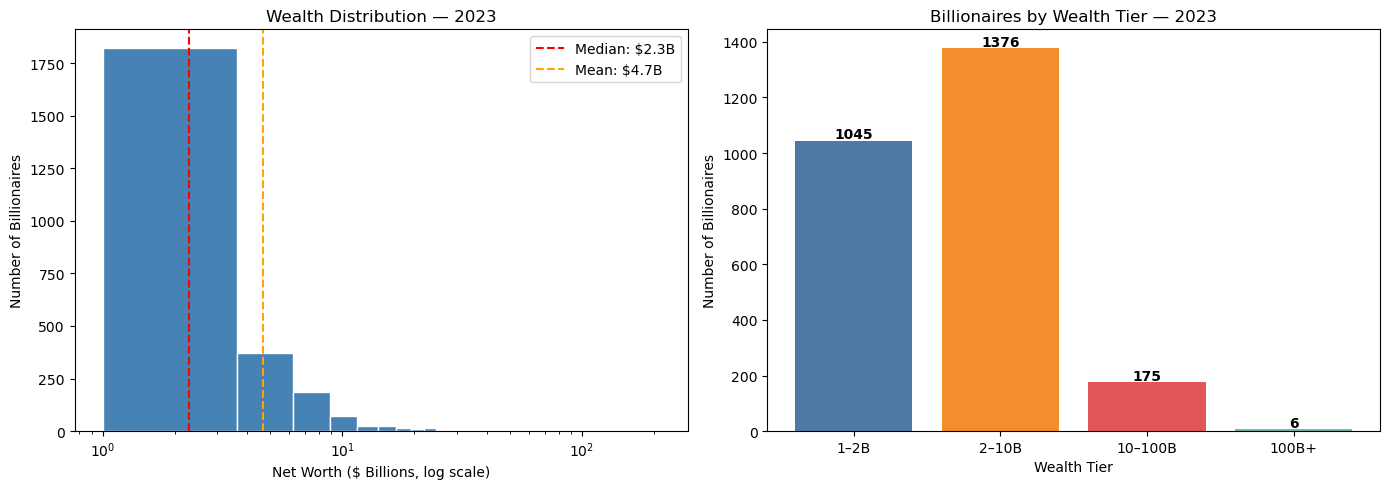

Median net worth : $2.3B
Mean net worth   : $4.7B
Top 1% threshold : $42.9B


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# df still has finalWorth (millions); df_2023 has worth_billions
worth = df_2023['worth_billions']

# --- Left: histogram of worth (log scale) ---
axes[0].hist(worth, bins=80, color='steelblue', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('Net Worth ($ Billions, log scale)')
axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Wealth Distribution — 2023')
axes[0].axvline(worth.median(), color='red',    linestyle='--', label=f"Median: ${worth.median():.1f}B")
axes[0].axvline(worth.mean(),   color='orange', linestyle='--', label=f"Mean: ${worth.mean():.1f}B")
axes[0].legend()

# --- Right: wealth tier bar chart ---
tier_counts = df_2023['worth_tier'].value_counts().sort_index()
axes[1].bar(tier_counts.index, tier_counts.values, color=['#4e79a7','#f28e2b','#e15759','#76b7b2'])
axes[1].set_xlabel('Wealth Tier')
axes[1].set_ylabel('Number of Billionaires')
axes[1].set_title('Billionaires by Wealth Tier — 2023')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Median net worth : ${worth.median():.1f}B")
print(f"Mean net worth   : ${worth.mean():.1f}B")
print(f"Top 1% threshold : ${worth.quantile(0.99):.1f}B")

### EDA 2: Top Countries (2023)

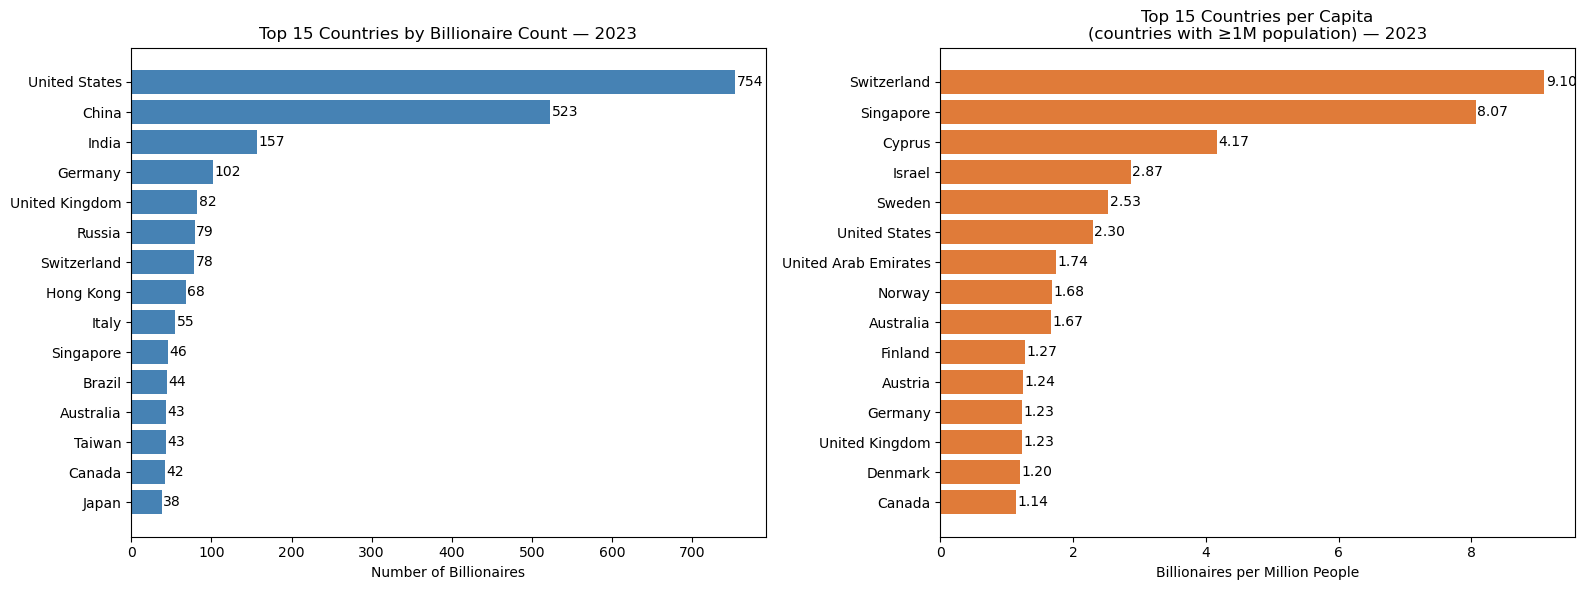

US share of all billionaires: 29.0%


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: top 15 countries by total count ---
top_countries = df_2023['country'].value_counts().head(15)

axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color='steelblue')
axes[0].set_xlabel('Number of Billionaires')
axes[0].set_title('Top 15 Countries by Billionaire Count — 2023')
for i, v in enumerate(top_countries.values[::-1]):
    axes[0].text(v + 2, i, str(v), va='center')

# --- Right: top 15 countries by billionaires per million (exclude micro-states <1M pop) ---
country_stats_filtered = country_stats[country_stats['population_country'] >= 1_000_000]
top_per_cap = country_stats_filtered.sort_values('billionaires_per_million', ascending=False).head(15)

axes[1].barh(top_per_cap['country'][::-1], top_per_cap['billionaires_per_million'][::-1], color='#e07b39')
axes[1].set_xlabel('Billionaires per Million People')
axes[1].set_title('Top 15 Countries per Capita\n(countries with ≥1M population) — 2023')
for i, v in enumerate(top_per_cap['billionaires_per_million'][::-1]):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

print(f"US share of all billionaires: {top_countries['United States'] / len(df_2023) * 100:.1f}%")

### EDA 3: Industry Breakdown (2023)

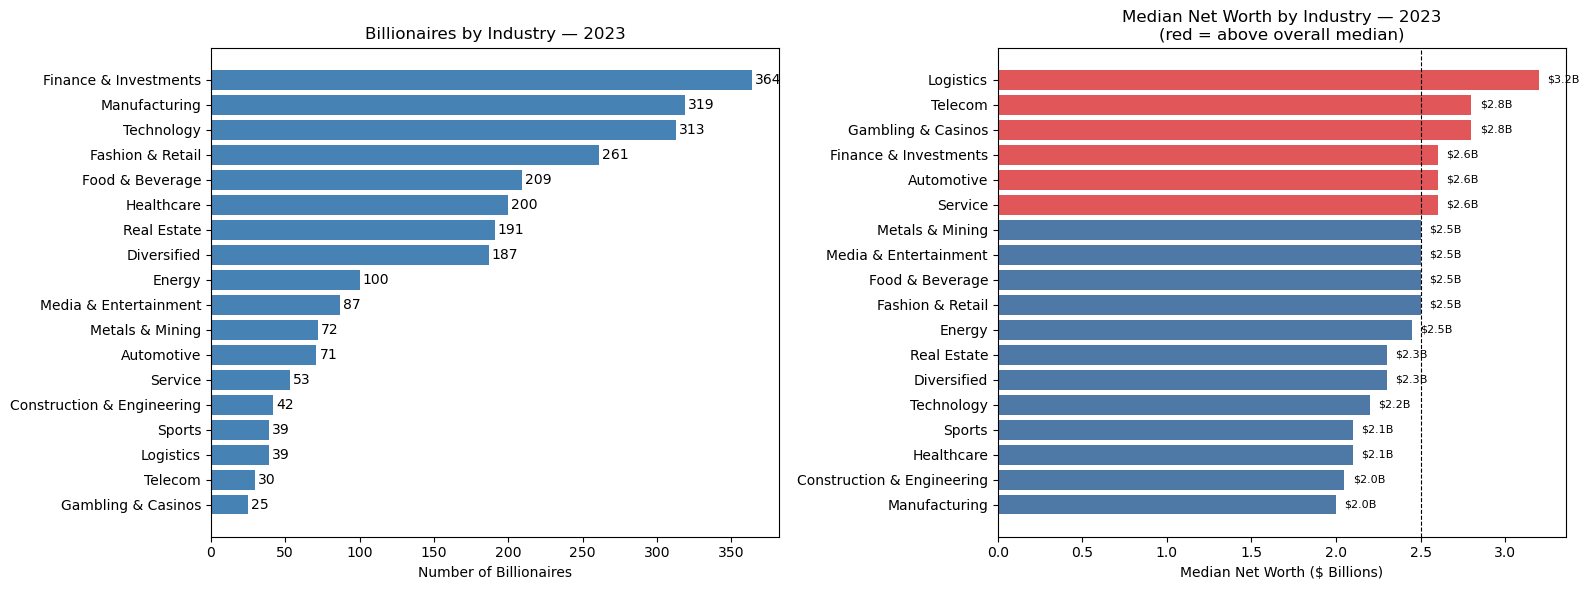

Top 3 industries by count:
industry
Finance & Investments    364
Manufacturing            319
Technology               313

Top 3 industries by median wealth:
industry
Logistics            3.20
Telecom              2.80
Gambling & Casinos   2.80


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: billionaire count by industry ---
industry_counts = df_2023['industry'].value_counts()

axes[0].barh(industry_counts.index[::-1], industry_counts.values[::-1], color='steelblue')
axes[0].set_xlabel('Number of Billionaires')
axes[0].set_title('Billionaires by Industry — 2023')
for i, v in enumerate(industry_counts.values[::-1]):
    axes[0].text(v + 2, i, str(v), va='center')

# --- Right: median net worth by industry ---
industry_worth = (df_2023.groupby('industry')['worth_billions']
                  .median()
                  .sort_values(ascending=True))

colors = ['#e15759' if v > industry_worth.median() else '#4e79a7' for v in industry_worth.values]
axes[1].barh(industry_worth.index, industry_worth.values, color=colors)
axes[1].set_xlabel('Median Net Worth ($ Billions)')
axes[1].set_title('Median Net Worth by Industry — 2023\n(red = above overall median)')
axes[1].axvline(industry_worth.median(), color='black', linestyle='--', linewidth=0.8)
for i, v in enumerate(industry_worth.values):
    axes[1].text(v + 0.05, i, f'${v:.1f}B', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Top 3 industries by count:")
print(industry_counts.head(3).to_string())
print("\nTop 3 industries by median wealth:")
print(industry_worth.sort_values(ascending=False).head(3).to_string())

### EDA 4: Self-Made vs Inherited — by Industry & Gender (2023)

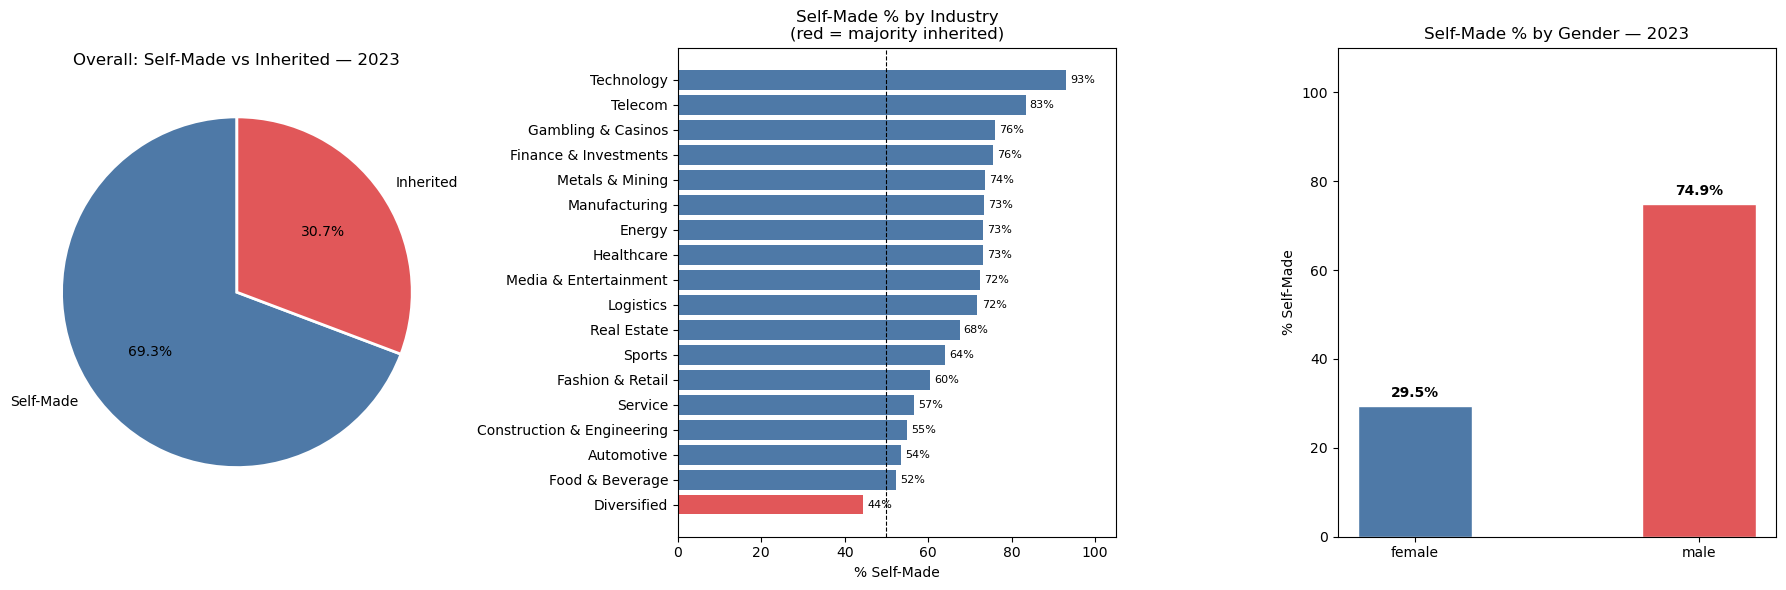

Self-made % by gender:
gender
female   29.50
male     74.90


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Left: overall self-made vs inherited pie ---
sm_counts = df_2023['self_made'].value_counts()
axes[0].pie(
    sm_counts.values,
    labels=['Self-Made', 'Inherited'],
    colors=['#4e79a7', '#e15759'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall: Self-Made vs Inherited — 2023')

# --- Middle: self-made % by industry (sorted) ---
sm_by_industry = (df_2023.groupby('industry')['self_made']
                  .mean()
                  .mul(100)
                  .round(1)
                  .sort_values())

colors_ind = ['#e15759' if v < 50 else '#4e79a7' for v in sm_by_industry.values]
axes[1].barh(sm_by_industry.index, sm_by_industry.values, color=colors_ind)
axes[1].axvline(50, color='black', linestyle='--', linewidth=0.8, label='50% line')
axes[1].set_xlabel('% Self-Made')
axes[1].set_title('Self-Made % by Industry\n(red = majority inherited)')
axes[1].set_xlim(0, 105)
for i, v in enumerate(sm_by_industry.values):
    axes[1].text(v + 1, i, f'{v:.0f}%', va='center', fontsize=8)

# --- Right: self-made % by gender ---
sm_by_gender = (df_2023.groupby('gender')['self_made']
                .mean()
                .mul(100)
                .round(1))

bar_colors = ['#4e79a7', '#e15759']
bars = axes[2].bar(sm_by_gender.index, sm_by_gender.values, color=bar_colors, width=0.4, edgecolor='white')
axes[2].set_ylabel('% Self-Made')
axes[2].set_title('Self-Made % by Gender — 2023')
axes[2].set_ylim(0, 110)
for bar, v in zip(bars, sm_by_gender.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Self-made % by gender:")
print(sm_by_gender.to_string())

### EDA 5: Trends Over Time (1996 → 2023)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Aggregate by year
yearly = df_merged.groupby('year').agg(
    count        = ('name', 'count'),
    self_made_pct= ('self_made', lambda x: x.mean() * 100),
    median_worth = ('worth_billions', 'median'),
).reset_index()

years = yearly['year']

# --- Left: total billionaire count per year ---
axes[0].bar(years, yearly['count'], color='steelblue', width=3)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Billionaire Count Over Time')
axes[0].set_xticks(years)
for i, (y, v) in enumerate(zip(years, yearly['count'])):
    axes[0].text(y, v + 20, str(v), ha='center', fontweight='bold')

# --- Middle: self-made % over time ---
axes[1].plot(years, yearly['self_made_pct'], marker='o', color='#4e79a7', linewidth=2.5, markersize=8)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% Self-Made')
axes[1].set_title('Self-Made % Over Time')
axes[1].set_xticks(years)
axes[1].set_ylim(50, 85)
axes[1].axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for y, v in zip(years, yearly['self_made_pct']):
    axes[1].text(y, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# --- Right: median net worth over time ---
axes[2].plot(years, yearly['median_worth'], marker='s', color='#e07b39', linewidth=2.5, markersize=8)
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Median Net Worth ($ Billions)')
axes[2].set_title('Median Net Worth Over Time')
axes[2].set_xticks(years)
for y, v in zip(years, yearly['median_worth']):
    axes[2].text(y, v + 0.05, f'${v:.1f}B', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nYearly summary:")
print(yearly.to_string(index=False))